# SMS Phishing Dataset EDA Notebook

This notebook performs exploratory data analysis (EDA) on the unified phishing SMS dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import os

# Load dataset
DATA_PATH = "../data/generated/unified_phishing_sms_dataset_processed.csv"
if not os.path.exists(DATA_PATH):
    print(f"ERROR: {DATA_PATH} not found. Please run the 'integrate_and_preprocess_datasets' method from data_preparation.py to generate the processed dataset.")
else:
    df = pd.read_csv(DATA_PATH)
    display(df.head())

,sms_content,is_phishing,dataset_source,has_url,has_email,has_phone_number,url_string,domain,tld,subdomain,...,domain_encoded,tld_encoded,subdomain_encoded,url_subcategory_encoded,domain_registrar_encoded,sender_encoded,sender_type_encoded,brand_encoded,message_category_encoded,dataset_source_encoded
0,"Go until jurong point, crazy.. Available only ...",0,D1,False,False,False,unknown,unknown,unknown,unknown,...,547,100,132,5,110,0,3,0,10,0
1,Ok lar... Joking wif u oni...,0,D1,False,False,False,unknown,unknown,unknown,unknown,...,547,100,132,5,110,0,3,0,10,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,D1,False,False,False,unknown,unknown,unknown,unknown,...,547,100,132,5,110,0,3,0,10,0
3,U dun say so early hor... U c already then say...,0,D1,False,False,False,unknown,unknown,unknown,unknown,...,547,100,132,5,110,0,3,0,10,0
4,"Nah I don't think he goes to usf, he lives aro...",0,D1,False,False,False,unknown,unknown,unknown,unknown,...,547,100,132,5,110,0,3,0,10,0


## 1. Basic Info & Summary

In [3]:
df.info()
df.describe(include="all")
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12605 entries, 0 to 12604
Data columns (total 47 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   sms_content                            12605 non-null  object 
 1   is_phishing                            12605 non-null  int64  
 2   dataset_source                         12605 non-null  object 
 3   has_url                                12605 non-null  bool   
 4   has_email                              12605 non-null  bool   
 5   has_phone_number                       12605 non-null  bool   
 6   url_string                             12605 non-null  object 
 7   domain                                 12605 non-null  object 
 8   tld                                    12605 non-null  object 
 9   subdomain                              12605 non-null  object 
 10  is_ip_address_url                      12605 non-null  object 
 11  re

424

## 2. Class Distribution

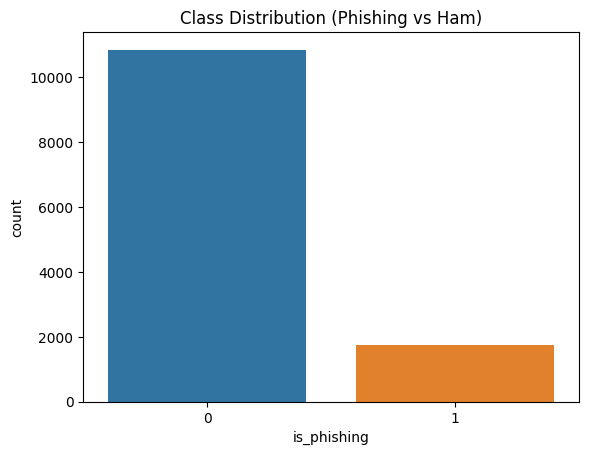

0    0.86069
1    0.13931
Name: is_phishing, dtype: float64

In [4]:
sns.countplot(x=df['is_phishing'])
plt.title("Class Distribution (Phishing vs Ham)")
plt.show()

df['is_phishing'].value_counts(normalize=True)

## 3. SMS Length Analysis

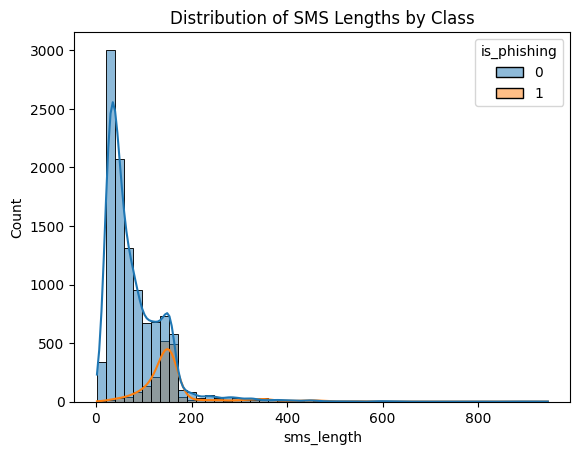

In [5]:
df['sms_length'] = df['sms_content'].astype(str).apply(len)
sns.histplot(df, x="sms_length", hue="is_phishing", bins=50, kde=True)
plt.title("Distribution of SMS Lengths by Class")
plt.show()

## 4. Common Tokens (WordCloud)

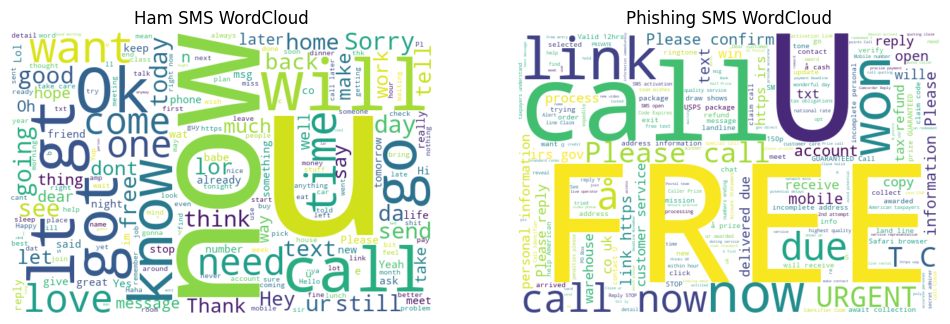

In [6]:
ham_texts = " ".join(df[df['is_phishing']==0]['sms_content'].astype(str))
spam_texts = " ".join(df[df['is_phishing']==1]['sms_content'].astype(str))

wc_ham = WordCloud(width=600, height=400, background_color="white", stopwords=STOPWORDS).generate(ham_texts)
wc_spam = WordCloud(width=600, height=400, background_color="white", stopwords=STOPWORDS).generate(spam_texts)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(wc_ham, interpolation="bilinear")
plt.axis("off")
plt.title("Ham SMS WordCloud")

plt.subplot(1,2,2)
plt.imshow(wc_spam, interpolation="bilinear")
plt.axis("off")
plt.title("Phishing SMS WordCloud")
plt.show()

## 5. Correlation Heatmap of Numeric Features

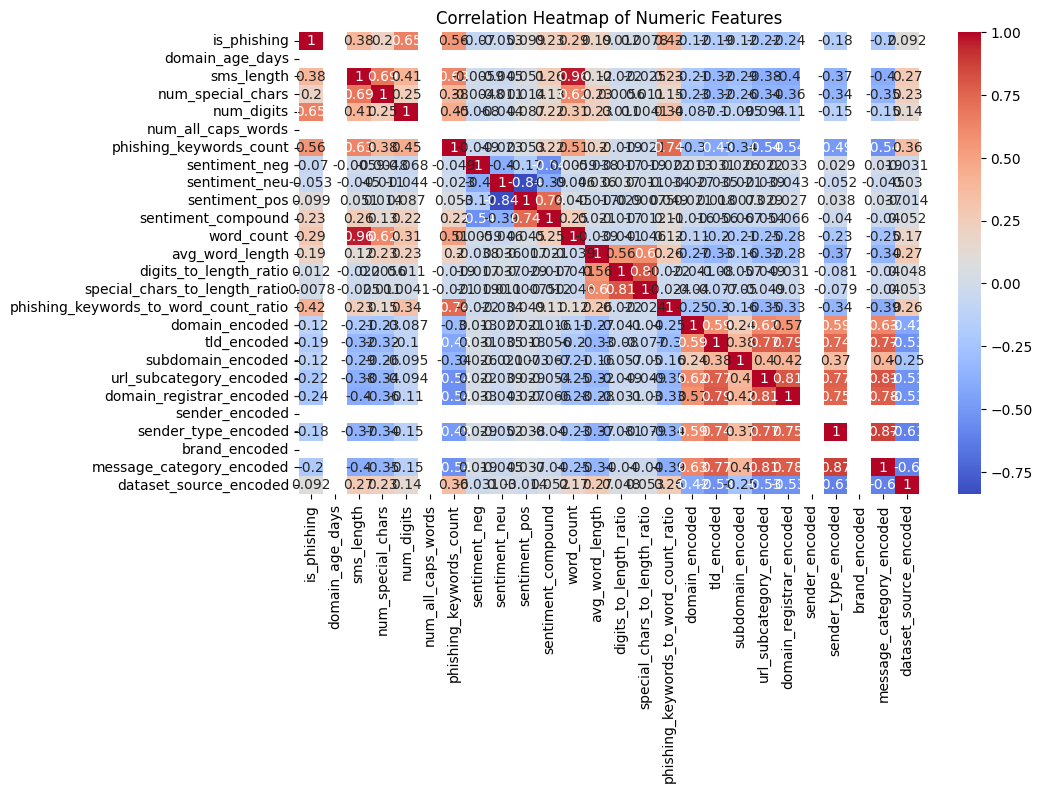

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## 6. URLs & Special Tokens

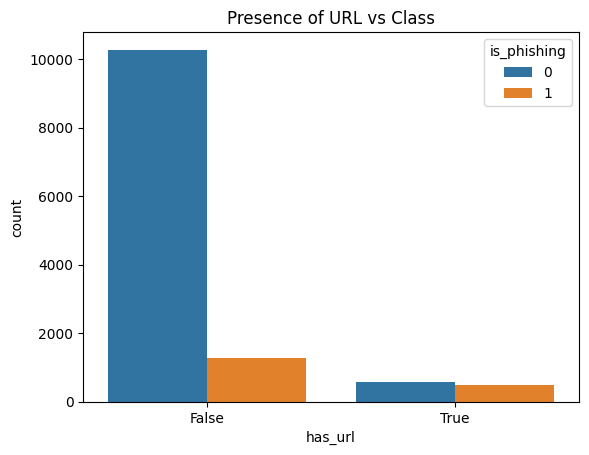

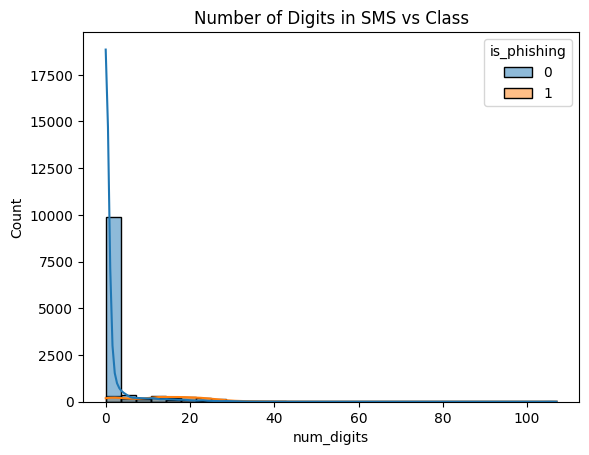

In [8]:
if 'has_url' in df.columns:
    sns.countplot(x=df['has_url'], hue=df['is_phishing'])
    plt.title("Presence of URL vs Class")
    plt.show()

if 'num_digits' in df.columns:
    sns.histplot(df, x="num_digits", hue="is_phishing", bins=30, kde=True)
    plt.title("Number of Digits in SMS vs Class")
    plt.show()

## 7. Next Steps
- Use DistilBERT tokenization for text representation.
- Engineer additional structured features (ratios, interactions).
- Prepare train/val/test splits for hybrid model.